# Model
This is the full 3D model from Optimal (Un)Conventional Monetary Policy (Andrey Alexandrov and Markus K. Brunnermeier). 

It does not require a separate planner model.  Instead, it:

1. solves the static constrained-efficient FOCs pointwise in ``sig2`` ($\tilde{\sigma}^2$);
2. differentiates the resulting allocation with autograd;
3. recovers the implementing policy fields from the paper's equations; and
4. solves the seven-unknown 3D PDE/algebraic system.

The efficient-path long-bond price is the restriction of the 3D ``PL`` network to ``(sig2, eta_eff(sig2), u_eff)``.  
Its total derivatives therefore remain coupled to the 3D solution, and ``PL(sig2_ss, eta_eff_ss, u_eff) = 1`` fixes the nominal price normalization.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

from deep_macrofin import (Comparator, LossReductionMethod, OptimizerType, PDEModel, set_seeds)

In [2]:
# Core parameter dictionary (planner real block + sticky-price / long-bond constants).
params = {
    # --- planner / real block ---
    "rho": 0.07,        # discount rate
    "a": 0.18,          # productivity
    "delta": 0.01,      # depreciation
    "phi": 5.0,         # investment adjustment
    "bs": 0.15,         # mean reversion of \tilde{sigma}^2
    "sig2_ss": 0.5,     # steady-state idiosyncratic risk
    "nus": 0.02,        # diffusion scale of \tilde{sigma}^2
    "varphi": 0.3,      # relative idiosyncratic loading
    "spp": 1.0,
    "lam_I": 0.18 * 0.001,   # type-switching intensity
    "sig2_min": 0.8,    # sig2 domain lower factor (times sig2_ss)
    "sig2_max": 1.2,    # sig2 domain upper factor (times sig2_ss)
    # --- sticky-price / long-bond block (needed for the 3D solve) ---
    "e": 10.0,          # demand elasticity (epsilon)
    "kappa": 100.0,     # Rotemberg adjustment cost
    "cnu": 0.1,         # transaction-cost level
    "nub": 4.4,         # transaction-cost scale
    "cp": 5.0,          # transaction-cost exponent
    "iL": 0.05,         # long-bond coupon
}

# Derived constants.
params["lam_H"] = params["lam_I"] / 9.0
params["lam"] = params["lam_H"] / (params["lam_I"] + params["lam_H"])
params["b"] = (
    params["a"]
    * (1 + params["rho"] * params["phi"])
    / (params["rho"] * (1 + params["a"] * params["phi"]) * (1 - params["lam"]))
)

# Grid / IRF settings.
Nsp = 2001      # fine grid used to read off the planner-derived policy fields
dZ = 1.0        # shock size for the impulse response
T_irf = 40.0
dt_irf = 0.01
ap = 5.0        # pre-shock window length

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "./models/full_eff_closed"

In [3]:
# ---------------------------------------------------------------------------
# Static constrained-efficient allocation (paper equations 118--120), 
# essentially the same equations as the 1D planner model
# ---------------------------------------------------------------------------
def compute_gamma(eta: torch.Tensor, rho: float, lam_I: float, lam_H: float, lam: float, varphi: float) -> torch.Tensor:
    """Gamma as a function of eta from the efficient allocation FOC."""
    denom = (1 - lam) * eta - lam * varphi**2 * (1 - eta)
    risk_denom = (1 - lam) * eta**2 + lam * varphi**2 * (1 - eta) ** 2
    switching = (
        (1 - lam) * (rho * (1 - eta) + lam_I) / (rho * (1 - eta) ** 2)
        - lam * (rho * eta + lam_H) / (rho * eta**2)
    )
    return switching * risk_denom / denom


def compute_theta_eff(gamma: torch.Tensor, rho: float, phi: float) -> torch.Tensor:
    return gamma / (1 + gamma) * (1 + rho * phi)


def compute_chi_eff(eta: torch.Tensor, lam: float, varphi: float) -> torch.Tensor:
    return (1 - lam) * eta**2 / ((1 - lam) * eta**2 + lam * varphi**2 * (1 - eta) ** 2)


def efficient_eta_residual(eta: torch.Tensor, sig2: torch.Tensor, p: dict) -> torch.Tensor:
    gamma = compute_gamma(eta, p["rho"], p["lam_I"], p["lam_H"], p["lam"], p["varphi"])
    theta = compute_theta_eff(gamma, p["rho"], p["phi"])
    risk_denom = (1 - p["lam"]) * eta**2 + p["lam"] * p["varphi"] ** 2 * (1 - eta) ** 2
    return gamma - (
        (1 - theta) ** 2 * sig2 * p["lam"] * (1 - p["lam"]) * p["varphi"] ** 2
        / (p["rho"] * risk_denom)
    )


def solve_eta_eff(sig2: torch.Tensor, p: dict, tol: float = 1e-10, max_iter: int = 40) -> torch.Tensor:
    """Solve the efficient eta FOC on the eta > lambda branch.

    The root is first found without retaining a growing graph.  Two final
    differentiable Newton corrections recover the exact first and second
    implicit derivatives at a converged root; those derivatives are needed for
    the efficient Ito drift and diffusion.
    """
    sig2_det = sig2.detach()
    eta = torch.full_like(sig2_det, 0.30)

    for _ in range(max_iter):
        eta_var = eta.detach().requires_grad_(True)
        residual = efficient_eta_residual(eta_var, sig2_det, p)
        derivative = torch.autograd.grad(
            residual,
            eta_var,
            grad_outputs=torch.ones_like(residual),
            create_graph=False,
        )[0]
        step = residual / derivative
        eta = (eta_var - step).detach().clamp(p["lam"] + 1e-5, 1 - 1e-5)
        if torch.max(torch.abs(step)).item() < tol:
            break

    # At the root, one Newton map has the exact implicit first derivative; a
    # second map has the exact second derivative.
    eta = eta.requires_grad_(True)
    for _ in range(2):
        residual = efficient_eta_residual(eta, sig2, p)
        derivative = torch.autograd.grad(
            residual,
            eta,
            grad_outputs=torch.ones_like(residual),
            create_graph=True,
            retain_graph=True,
        )[0]
        eta = eta - residual / derivative
    return eta


def solve_u_planner(p: dict) -> float:
    """Efficient utilization: the positive root of

        a (1 + rho phi) / (rho (1 + a phi u)) = (1 - lam) b'(u),   b'(u) = b u.

    Clearing the denominator leaves a quadratic, so take the root in closed
    form.  The calibration of `b` at the top of the file makes this exactly 1
    for any (a, rho, phi, lam), but it moves if `b` is overridden by hand.
    """
    quad = (1 - p["lam"]) * p["rho"] * p["b"] * p["a"] * p["phi"]
    lin = (1 - p["lam"]) * p["rho"] * p["b"]
    const = p["a"] * (1 + p["rho"] * p["phi"]) # note the constant term has a negative sign, but handled in the quadratic formula
    if abs(quad) < 1e-12:      # phi = 0: the FOC is linear in u
        return float(const / lin)
    return float((-lin + np.sqrt(lin**2 + 4 * quad * const)) / (2 * quad))


def efficient_levels(sig2: torch.Tensor, p: dict) -> dict[str, torch.Tensor]:
    """Efficient allocation levels at arbitrary sig2."""
    eta = solve_eta_eff(sig2, p)
    gamma = compute_gamma(eta, p["rho"], p["lam_I"], p["lam_H"], p["lam"], p["varphi"])
    theta = compute_theta_eff(gamma, p["rho"], p["phi"])
    chi = compute_chi_eff(eta, p["lam"], p["varphi"])
    u = torch.full_like(sig2, solve_u_planner(p))
    iota = (p["a"] * u * (1 - theta) - p["rho"]) / (1 - theta + p["rho"] * p["phi"])
    growth = torch.log(1 + p["phi"] * iota) / p["phi"] - p["delta"]
    return {
        "eta": eta,
        "gamma": gamma,
        "theta": theta,
        "chi": chi,
        "u": u,
        "iota": iota,
        "g": growth,
    }


def _first_second(value: torch.Tensor, state: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    first = torch.autograd.grad(
        value,
        state,
        grad_outputs=torch.ones_like(value),
        create_graph=True,
        retain_graph=True,
    )[0]
    second = torch.autograd.grad(
        first,
        state,
        grad_outputs=torch.ones_like(first),
        create_graph=True,
        retain_graph=True,
    )[0]
    return first, second


def efficient_ito_objects(sig2: torch.Tensor, p: dict) -> dict[str, torch.Tensor]:
    """Efficient levels and geometric Ito drifts/diffusions."""
    levels = efficient_levels(sig2, p)
    deta, d2eta = _first_second(levels["eta"], sig2)
    dtheta, d2theta = _first_second(levels["theta"], sig2)

    mu_s = p["bs"] * (p["sig2_ss"] - sig2)
    sig_s = p["nus"] * torch.sqrt(sig2) ** p["spp"]

    levels.update(
        {
            "mu_s": mu_s,
            "sig_s": sig_s,
            "mu_eta": (deta * mu_s + 0.5 * d2eta * sig_s**2) / levels["eta"],
            "sig_eta": deta * sig_s / levels["eta"],
            "mu_theta": (dtheta * mu_s + 0.5 * d2theta * sig_s**2) / levels["theta"],
            "sig_theta": dtheta * sig_s / levels["theta"],
        }
    )
    return levels

# --------------------------------------------------------------------------------------------
# the domain for solving will be recomputed using the following functions based on parameters
# --------------------------------------------------------------------------------------------

def efficient_domain(p: dict, padding: float = 0.03) -> tuple[float, float, float, float, float]:
    """State bounds and efficient steady state from the economic FOCs."""
    sig2_lo = p["sig2_ss"] * p["sig2_min"]
    sig2_hi = p["sig2_ss"] * p["sig2_max"]
    points = torch.tensor([[sig2_lo], [p["sig2_ss"]], [sig2_hi]], dtype=torch.float32, device=DEVICE)
    levels = efficient_levels(points, p)
    eta_values = levels["eta"].detach().cpu().numpy().reshape(-1)
    theta_ss = float(levels["theta"][1].detach().cpu())
    return (
        sig2_lo,
        sig2_hi,
        float(eta_values.min() - padding),
        float(eta_values.max() + padding),
        theta_ss,
    )


def u_domain(p: dict, halfwidth: float = 0.05) -> list[float]:
    """Utilization box: a relative band around the efficient root.

    Utilization is block-recursive -- it drops out of the (eta, gamma, theta)
    system and only enters iota downstream -- so it gets its own bounds rather
    than coming out of `efficient_domain`.
    """
    u_star = solve_u_planner(p)
    return [u_star * (1 - halfwidth), u_star * (1 + halfwidth)]


def efficient_steady_state(p: dict) -> tuple[float, float]:
    """Efficient eta and theta at the stochastic steady state."""
    sig2_ss = torch.tensor([[p["sig2_ss"]]], dtype=torch.float32, device=DEVICE)
    levels = efficient_levels(sig2_ss, p)
    eta_ss = float(levels["eta"].detach().cpu())
    theta_ss = float(levels["theta"].detach().cpu())
    return eta_ss, theta_ss

In [4]:
# ---------------------------------------------------------------------------
# Efficient-policy closure
# ---------------------------------------------------------------------------
def compute_policy(SV: torch.Tensor, compute_PI, compute_PL, compute_v, compute_chi, compute_alph, compute_nu, compute_sig_eta) -> torch.Tensor:
    """Return policy fields and efficient-path residuals at sampled sig2.

    Columns are ``[vL, tau_x, i, iR, s_check, tau_I, tau, sigPL_gap, pi_gap,
    v_gap, chi_gap, alph_gap, nu_gap, sig_eta_gap]``.

    The efficient allocation is determined from the paper's FOCs, not from a
    planner network.  The 3D PL network is evaluated along the efficient path,
    keeping the policy block coupled to the equilibrium PDE.
    """
    p = MODEL_PARAMS
    sig2_input = SV[:, 0:1]
    sig2 = sig2_input.detach().clone().requires_grad_(True)
    eff = efficient_ito_objects(sig2, p)

    eta = eff["eta"]
    v = eff["theta"]
    chi = eff["chi"]
    sig_eta = eff["sig_eta"]
    sig_v = eff["sig_theta"]
    mu_eta = eff["mu_eta"]
    mu_v = eff["mu_theta"]
    growth = eff["g"]

    sig_B = (1 + p["rho"] * p["phi"]) / (1 - v + p["rho"] * p["phi"]) * sig_v

    # Efficient intermediary share of long bonds (alpha = eta^L).
    alpha = ((eta * sig_eta - (eta - chi) * sig_v) / sig_B - chi + eta) / v + chi

    cfp = lambda x: (p["cnu"] * p["cp"] * x ** (p["cp"] - 1) / p["nub"] ** p["cp"])
    cfpp = lambda x: (p["cnu"] * p["cp"] * (p["cp"] - 1)  * x ** (p["cp"] - 2)/ p["nub"] ** p["cp"])

    # Equations (efficient-velocity-1)--(efficient-velocity-2), reduced to
    # one scalar equation in efficient deposit velocity.  Appendix C.3 may
    # admit more than one mathematical root, so use several Newton starts and
    # retain only roots satisfying nu>0 and 0<vL<1.
    A = chi - eta + v * (1 - chi)
    denom = (1 - alpha) * v
    target = sig_eta / (1 - eta) * sig_B
    safe_denom = torch.where(
        torch.abs(denom) < 1e-8,
        torch.where(denom >= 0, 1e-8, -1e-8),
        denom,
    )

    candidates = []
    candidate_scores = []
    for start_scale in (0.10, 0.25, 0.50, 0.75, 1.00, 1.50):
        nu_try = torch.full_like(v, p["nub"] * start_scale)
        for _ in range(30):
            residual = nu_try * cfp(nu_try) * (nu_try * A - (1 - v)) / safe_denom - target
            derivative = (
                cfp(nu_try) * (nu_try * A - (1 - v)) / safe_denom
                + nu_try
                * cfpp(nu_try)
                * (nu_try * A - (1 - v))
                / safe_denom
                + nu_try * cfp(nu_try) * A / safe_denom
            )
            safe_derivative = torch.where(
                torch.abs(derivative) < 1e-10,
                torch.where(derivative >= 0, 1e-10, -1e-10),
                derivative,
            )
            nu_try = torch.clamp(nu_try - residual / safe_derivative, min=1e-5, max=10 * p["nub"],)

        vL_try = (nu_try * A - (1 - v)) / safe_denom / nu_try
        final_residual = nu_try * cfp(nu_try) * (nu_try * A - (1 - v)) / safe_denom - target

        admissible = (
            torch.isfinite(nu_try)
            & torch.isfinite(vL_try)
            & (nu_try > 0)
            & (vL_try > 0)
            & (vL_try < 1)
        )
        score = (
            torch.abs(final_residual) / (torch.abs(target) + 1e-8)
            + (~admissible).to(final_residual.dtype) * 1e6
            # Deterministic selection if two admissible roots have equal residual.
            + 1e-8 * torch.abs(nu_try - p["nub"] / 2)
        )
        candidates.append(nu_try)
        candidate_scores.append(score)

    candidate_tensor = torch.stack(candidates, dim=0)
    score_tensor = torch.stack(candidate_scores, dim=0)
    best_index = torch.argmin(score_tensor, dim=0, keepdim=True)
    nu_general = torch.gather(candidate_tensor, 0, best_index).squeeze(0)
    vL_general = (nu_general * A - (1 - v)) / safe_denom / nu_general

    # Exact limiting solution when alpha=eta^L=1.
    safe_A = torch.where(torch.abs(A) < 1e-8, torch.where(A >= 0, 1e-8, -1e-8), A)
    nu_alpha_one = (1 - v) / safe_A
    vL_alpha_one = target / (nu_alpha_one**2 * cfp(nu_alpha_one) + 1e-12)
    alpha_one = torch.abs(1 - alpha) < 1e-6
    nu_eff = torch.where(alpha_one, nu_alpha_one, nu_general)
    vL = torch.where(alpha_one, vL_alpha_one, vL_general)
    sig_PL = sig_B / vL

    # Restrict the 3D long-bond price to the efficient path and take total
    # derivatives with respect to sig2.
    path_state = torch.cat([sig2, eta, torch.full_like(sig2, solve_u_planner(p))], dim=1)
    PL_eff = compute_PL(path_state)
    pi_eff = compute_PI(path_state)
    dPL, d2PL = _first_second(PL_eff, sig2)
    mu_PL = (dPL * eff["mu_s"] + 0.5 * d2PL * eff["sig_s"] ** 2) / PL_eff
    sig_PL_from_path = dPL * eff["sig_s"] / PL_eff
    sig_PL_gap = sig_PL_from_path - sig_PL

    # Equation (efficient-i).  At convergence sig_PL_from_path = sig_PL;
    # using the path derivative here couples the implementing rate to PL.
    i_rate = mu_PL + p["iL"] / PL_eff - sig_PL_from_path * (sig_eta + sig_B - sig_v)

    sig_tI = (1 - v) * chi / eta * p["varphi"] * torch.sqrt(sig2)
    sig_tH = (1 - v) * (1 - chi) / (1 - eta) * torch.sqrt(sig2)
    total_variance = eta * (sig_eta**2 + sig_tI**2) + (1 - eta) * ((eta * sig_eta / (1 - eta)) ** 2 + sig_tH**2)

    tau_x = (
        (sig_B - sig_v / (1 - v)) * sig_eta / (1 - eta)
        + (1 - v) * (chi * (p["varphi"] ** 2 * (1 - eta) + eta) - eta)
        / eta
        / (1 - eta)
        * sig2
        - nu_eff**2 * cfp(nu_eff)
    )

    mu_B = (1 + p["rho"] * p["phi"]) / (1 - v + p["rho"] * p["phi"]) * (mu_v - sig_v * (sig_v - sig_B)) + growth

    iR = (
        mu_B
        - i_rate * (vL + (1 - v) * (1 - vL))
        + p["rho"]
        - total_variance
        - sig_eta * sig_PL
        + chi * (1 - v) * tau_x
        - mu_v
        - sig_B * (sig_B - sig_v)
    ) / v / (1 - vL)

    s_check = (
        p["rho"]
        - total_variance
        - (1 - v) * (1 - vL) * (i_rate - iR)
        + (sig_B - sig_PL) * sig_eta
        + chi * (1 - v) * tau_x
        - mu_v
    )

    tau_I = (
        mu_eta
        - (1 - eta)
        * (
            sig_eta**2
            + sig_tI**2
            - (eta * sig_eta / (1 - eta)) ** 2
            - sig_tH**2
            - nu_eff**2 * cfp(nu_eff)
            - (1 - vL) * v / eta * (i_rate - iR)
        )
        - chi * (1 - v) * tau_x
        + sig_eta * (sig_v - sig_B)
        + p["lam_I"]
        - p["lam_H"] * (1 - eta) / eta
    )

    # State-dependent monopolistic-firm subsidy from Appendix C.3.  It makes
    # pi=0 on the efficient path.
    qK_eff = 1 + p["phi"] * eff["iota"]
    pR_eff = (
        p["rho"]
        * p["b"]
        * solve_u_planner(p)
        * (1 - eta)
        * qK_eff
        / (p["a"] * (1 - v))
    )
    tau_prod = 1 - ((p["e"] - 1) / p["e"]) / pR_eff

    # On the efficient manifold the equilibrium allocation must coincide with
    # the efficient one.  These gaps are implied by F1--F4 given the policy
    # fields, but imposing them keeps the 3D solution anchored to the manifold
    # instead of only matching it in levels.
    v_gap = compute_v(path_state) - v
    chi_gap = compute_chi(path_state) - chi
    alph_gap = compute_alph(path_state) - alpha
    nu_gap = compute_nu(path_state) - nu_eff
    sig_eta_gap = compute_sig_eta(path_state) - sig_eta

    return torch.cat(
        [vL, tau_x, i_rate, iR, s_check, tau_I, tau_prod, 
         sig_PL_gap, pi_eff, v_gap, chi_gap, alph_gap, nu_gap, sig_eta_gap,],
        dim=1,
    )

In [5]:
# ---------------------------------------------------------------------------
# 3D equilibrium helpers
# ---------------------------------------------------------------------------
def compute_sig_s(sig2: torch.Tensor, nus: float, spp: float) -> torch.Tensor:
    return nus * torch.sqrt(sig2) ** spp

def compute_iota(v: torch.Tensor, u: torch.Tensor, a: float, rho: float, phi: float) -> torch.Tensor:
    return (a * u - rho / (1 - v)) / (1 + rho * phi / (1 - v))

def compute_Phi(iota: torch.Tensor, phi: float) -> torch.Tensor:
    return torch.log(1 + phi * iota) / phi

def compute_bfp(u: torch.Tensor, b: float) -> torch.Tensor:
    return b * u

def compute_cfp(nu: torch.Tensor, cnu: float, cp: float, nub: float) -> torch.Tensor:
    return cnu * cp * nu ** (cp - 1) / nub**cp

def compute_generator(Jac: torch.Tensor,Hess: torch.Tensor,
    mu_s: torch.Tensor, MU: torch.Tensor, MUu: torch.Tensor,
    sig_s: torch.Tensor, S: torch.Tensor, Su: torch.Tensor,
) -> torch.Tensor:
    """Rank-one infinitesimal generator for the single aggregate shock."""
    mu_vec = torch.cat([mu_s, MU, MUu], dim=1)
    sig_vec = torch.cat([sig_s, S, Su], dim=1)
    drift = torch.einsum("bi,boi->bo", mu_vec, Jac)
    diffusion = 0.5 * torch.einsum(
        "bi,boij,bj->bo", sig_vec, Hess, sig_vec
    )
    return drift + diffusion

In [6]:
MODEL_PARAMS = dict(params)

MODEL_FUNCS = [
    compute_policy,
    compute_sig_s,
    compute_iota,
    compute_Phi,
    compute_bfp,
    compute_cfp,
    compute_generator,
]

def get_model(model_path, model_size: list[int], 
              batch_size: int = 2000, num_epochs: int = 3000, lr: float = 1e-3,
) -> PDEModel:
    """Build, optionally train, and load the closed 3D model."""
    global MODEL_PARAMS

    sig2_lo, sig2_hi, eta_lo, eta_hi, _ = efficient_domain(MODEL_PARAMS)
    eta_ss, _ = efficient_steady_state(MODEL_PARAMS)

    set_seeds(42)
    model = PDEModel("full_eff_closed",
        config={
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "optimizer_type": OptimizerType.Adam,
            "lr": lr,
            "stacked": True,
        },
    )
    model.set_state(
        ["sig2", "eta", "u"],
        {
            "sig2": [sig2_lo, sig2_hi],
            "eta": [eta_lo, eta_hi],
            "u": u_domain(MODEL_PARAMS),
        },
    )
    model.add_params(MODEL_PARAMS)

    pde_cfg = {"hidden_units": model_size, "batch_jac_hes": True}
    point_cfg = {"hidden_units": model_size, "derivative_order": 0}
    model.add_endog("v", config={**pde_cfg, "positive": True})
    model.add_endog("PL", config={**pde_cfg, "positive": True})
    model.add_endog("pie", config=pde_cfg)
    model.add_endog("sig_eta", config=point_cfg)
    model.add_endog("chi", config=point_cfg)
    model.add_endog("alph", config=point_cfg)
    model.add_endog("nu", config={**point_cfg, "positive": True})
    model.register_functions(MODEL_FUNCS)

    model.add_equations(
        [
            # Policy closure from the embedded efficient allocation.
            "policy=compute_policy(SV,compute_pie, compute_PL, compute_v, compute_chi, compute_alph, compute_nu, compute_sig_eta)",
            "vL=policy[:, 0:1]",
            "tau_x=policy[:, 1:2]",
            "iT=policy[:, 2:3]",
            "iR=policy[:, 3:4]",
            "s_check=policy[:, 4:5]",
            "tau_I=policy[:, 5:6]",
            "tau_prod=policy[:, 6:7]",
            "efficient_sigPL_gap=policy[:, 7:8]",
            "efficient_pi_gap=policy[:, 8:9]",
            "efficient_v_gap=policy[:, 9:10]",
            "efficient_chi_gap=policy[:, 10:11]",
            "efficient_alph_gap=policy[:, 11:12]",
            "efficient_nu_gap=policy[:, 12:13]",
            "efficient_sig_eta_gap=policy[:, 13:14]",
            "sig_s=compute_sig_s(sig2, nus, spp)",
            # Market and auxiliary equations.
            "iota=compute_iota(v, u, a, rho, phi)",
            "qK=1+phi*iota",
            "qB=v*qK/(1-v)",
            "g=compute_Phi(iota, phi)-delta",
            "pR=rho*compute_bfp(u, b)*(1-eta)*qK/(a*(1-v))",
            # Elasticities of the PDE unknowns.
            "vaux_s=v_Jac[:, 0, 0:1]/v",
            "vaux_e=v_Jac[:, 0, 1:2]/v",
            "vaux_u=v_Jac[:, 0, 2:3]/v",
            "PLaux_s=PL_Jac[:, 0, 0:1]/PL",
            "PLaux_e=PL_Jac[:, 0, 1:2]/PL",
            "PLaux_u=PL_Jac[:, 0, 2:3]/PL",
            # Utilization diffusion: sigma^u = a0 + a1 eta sigma^eta.
            "denom=a*phi*v/qB+(1+rho*phi)*vaux_u-(1-v+rho*phi)*vL*PLaux_u",
            "a0=((1-v+rho*phi)*vL*PLaux_s-(1+rho*phi)*vaux_s)/denom*sig_s",
            "a1=((1-v+rho*phi)*vL*PLaux_e-(1+rho*phi)*vaux_e)/denom",
            "S=eta*sig_eta",
            "sig_ups=a0+a1*S",
            # Aggregate and idiosyncratic risk loadings.
            "sig_v=vaux_e*S+vaux_s*sig_s+vaux_u*sig_ups",
            "sig_PL=PLaux_e*S+PLaux_s*sig_s+PLaux_u*sig_ups",
            "sig_B=vL*sig_PL",
            "sig_H=-eta/(1-eta)*sig_eta",
            "sig_tI=(1-v)*chi/eta*varphi*sqrt(sig2)",
            "sig_tH=(1-v)*(1-chi)/(1-eta)*sqrt(sig2)",
            "cfpnu=compute_cfp(nu, cnu, cp, nub)",
            # State drifts.
            "mu_s=-bs*(sig2-sig2_ss)",
            "mu_B=iR+vL*(iT-iR)-s_check+sig_B*(sig_eta-sig_v+sig_B)",
            "mu_qB=mu_B-pie-g",
            "mu_v=rho-s_check+sig_H*sig_v-(1-v)*((1-vL)*(iT-iR)+(1-vL+1/nu)*nu**2*cfpnu+sig_tH*sqrt(sig2))",
            "mu_eta_rate=mu_v+s_check-rho+(1-vL)*(iT-iR)*(1-v/eta)+(sig_eta-sig_v)*sig_eta+sig_tI**2+tau_I-lam_I+lam_H*(1-eta)/eta",
            "MU=eta*mu_eta_rate",
            "mu_PL=iT-iL/PL+sig_PL*(sig_eta+sig_B-sig_v)",
            "MUu=qB/(a*phi*v)*(mu_qB*(1-v+rho*phi)+(1+rho*phi)*(sig_v*(sig_v-sig_B)-mu_v))",
            # Rotemberg inflation drift.
            "sig_N=sig_B-sig_v",
            "mu_N=mu_B-pie-mu_v-sig_v*sig_N",
            "sig_NH=sig_H+sig_N",
            "mu_ome=-eta*mu_eta_rate/(1-eta)",
            "mu_NH=mu_ome+mu_N+sig_H*sig_N",
            "rf=rho+mu_NH-sig_NH**2",
            "SIG_pie=pie_Jac[:, 0, 0:1]*sig_s+pie_Jac[:, 0, 1:2]*S+pie_Jac[:, 0, 2:3]*sig_ups",
            "MU_pie=pie*(rf-MUu/u-g+sig_NH*sig_ups/u)-e/kappa*(pR*(1-tau_prod)-(e-1)/e)+SIG_pie*(sig_NH-sig_ups/u)",
            # Infinitesimal generator.
            "Lv=compute_generator(v_Jac, v_Hess, mu_s, MU, MUu, sig_s, S, sig_ups)",
            "LPL=compute_generator(PL_Jac, PL_Hess, mu_s, MU, MUu, sig_s, S, sig_ups)",
            "Lpie=compute_generator(pie_Jac, pie_Hess, mu_s, MU, MUu, sig_s, S, sig_ups)",
        ]
    )

    # Pointwise algebraic system F1--F4.
    model.add_endog_equation("eta*sig_eta+(chi-eta)*sig_v+(eta-chi-v*(alph-chi))*vL*sig_PL=0", label="F1")
    model.add_endog_equation(
        "sig_eta*((vL-1)*sig_PL-sig_v/(1-v))+(1-v)*(chi*(eta+(1-eta)*varphi**2)-eta)/eta*sig2-tau_x*(1-eta)=0",
        label="F2",
    )
    model.add_endog_equation("sig_eta*sig_PL-nu**2*cfpnu*(1-eta)=0", label="F3")
    model.add_endog_equation("nu*(1-(1-chi)*(1-v)/(1-eta)-(1-alph)*vL*v/(1-eta))-(1-v)/(1-eta)=0", label="F4")

    # Stationary PDEs.
    model.add_endog_equation("Lv=mu_v*v", label="hjb_v", loss_reduction=LossReductionMethod.MAE)
    model.add_endog_equation("LPL=mu_PL*PL", label="hjb_PL", loss_reduction=LossReductionMethod.MAE)
    model.add_endog_equation("Lpie=MU_pie", label="hjb_pie", loss_reduction=LossReductionMethod.MAE)

    # Efficient-path implementation conditions.  These enforce the ODE for
    # P^L along the one-dimensional efficient manifold and pi*=0 there.
    model.add_endog_equation("efficient_sigPL_gap=0", label="efficient_path_sigPL", loss_reduction=LossReductionMethod.MAE)
    model.add_endog_equation("efficient_pi_gap=0", label="efficient_path_pi", loss_reduction=LossReductionMethod.MAE,)

    # Anchor the 3D allocation to the efficient allocation on the manifold.
    # Without these the solution matches the efficient levels but not its
    # diffusion, so the manifold is not invariant under the solved dynamics.
    for gap, label in (
        ("efficient_v_gap", "efficient_path_v"),
        ("efficient_chi_gap", "efficient_path_chi"),
        ("efficient_alph_gap", "efficient_path_alph"),
        ("efficient_nu_gap", "efficient_path_nu"),
        ("efficient_sig_eta_gap", "efficient_path_sig_eta"),
    ):
        model.add_endog_equation(f"{gap}=0", label=label, loss_reduction=LossReductionMethod.MAE)

    # Efficient-path bond-price normalization.
    norm_state = torch.tensor(
        [[MODEL_PARAMS["sig2_ss"], eta_ss, solve_u_planner(MODEL_PARAMS)]],
        dtype=torch.float32,
        device=model.device,
    )
    model.add_endog_condition(
        "PL", "PL(SV)", {"SV": norm_state},
        Comparator.EQ,
        "1", {},
        label="efficient_ss_normalization",
        weight=100.0,
    )

    os.makedirs(model_path, exist_ok=True)
    checkpoint = os.path.join(model_path, "model.pt")
    best_checkpoint = os.path.join(model_path, "model_best.pt")
    if not os.path.exists(checkpoint):
        model.train_model(model_path, "model.pt", True)
    model.load_model(torch.load(best_checkpoint, weights_only=False))
    return model

In [7]:
def evaluate_at(model: PDEModel, states: np.ndarray, names: list[str]) -> dict[str, np.ndarray]:
    """Evaluate model variables at rows of (sig2, eta, u)."""
    SV = torch.tensor(
        np.atleast_2d(states),
        dtype=torch.float32,
        device=model.device,
        requires_grad=True,
    )
    values = model.variable_val_dict.copy()
    model.update_variables(SV, vd=values)
    return {
        name: values[name].detach().cpu().numpy().reshape(-1)
        for name in names
    }


STATE_NAMES = ("sig2", "eta", "u")
OBSERVABLE_NAMES = ("v", "chi", "pie", "iT", "iR", "PL", "vL", "iota")
DYNAMICS_NAMES = ("mu_s", "MU", "MUu", "sig_s", "S", "sig_ups")


def _state_bounds(model: PDEModel) -> tuple[np.ndarray, np.ndarray]:
    low = np.asarray(model.state_variable_constraints["sv_low"], dtype=np.float64)
    high = np.asarray(model.state_variable_constraints["sv_high"], dtype=np.float64)
    return low, high


def _clip_states(model: PDEModel, states: np.ndarray) -> np.ndarray:
    low, high = _state_bounds(model)
    eps = 1e-6 * np.maximum(high - low, 1.0)
    return np.clip(states, low + eps, high - eps)


def _evaluate_simulation_block(
    model: PDEModel, states: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    names = list(DYNAMICS_NAMES + OBSERVABLE_NAMES)
    values = evaluate_at(model, states, names)
    drift = np.column_stack([values["mu_s"], values["MU"], values["MUu"]])
    diffusion = np.column_stack([values["sig_s"], values["S"], values["sig_ups"]])
    observables = np.column_stack([values[name] for name in OBSERVABLE_NAMES])
    return drift, diffusion, observables


def _derived_observables(observables: np.ndarray) -> dict[str, np.ndarray]:
    index = {name: i for i, name in enumerate(OBSERVABLE_NAMES)}
    vL = observables[..., index["vL"]]
    PL = observables[..., index["PL"]]
    psi = vL / (1 - vL) / PL
    return {"psi": psi}


# Reported impulse responses: "pct" is a percent deviation from the steady
# state, "diff" is a level difference in percentage points.
IRF_RESPONSES: dict[str, tuple[str, str]] = {
    "sig2": ("state:0", "pct"),
    "eta": ("state:1", "diff"),
    "u": ("state:2", "pct"),
    "v": ("obs:v", "diff"),
    "chi": ("obs:chi", "diff"),
    "pie": ("obs:pie", "diff"),
    "i": ("obs:iT", "diff"),
    "iR": ("obs:iR", "diff"),
    "PL": ("obs:PL", "pct"),
    "vL": ("obs:vL", "diff"),
    "iota": ("obs:iota", "diff"),
    "psi": ("derived:psi", "pct"),
}


def efficient_manifold_states(model: PDEModel, sig2_values: np.ndarray) -> np.ndarray:
    """Lift sig2 values onto the efficient manifold.

    The constrained-efficient allocation pins ``eta = eta_eff(sig2)`` and holds
    utilization at ``U_PLANNER``, so the whole efficient equilibrium is the
    one-dimensional curve traced by ``sig2``.
    """
    low, high = _state_bounds(model)
    sig2 = np.clip(np.asarray(sig2_values, dtype=np.float64).reshape(-1), low[0], high[0])
    tensor = torch.tensor(sig2.reshape(-1, 1), dtype=torch.float32, device=model.device)
    eta = solve_eta_eff(tensor, MODEL_PARAMS).detach().cpu().numpy().reshape(-1)
    states = np.column_stack([sig2, eta, np.full(sig2.size, solve_u_planner(MODEL_PARAMS))])
    return _clip_states(model, states)


def _evaluate_in_chunks(model: PDEModel, states: np.ndarray, chunk: int = 500) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    blocks = [
        _evaluate_simulation_block(model, states[start : start + chunk])
        for start in range(0, len(states), chunk)
    ]
    return tuple(np.concatenate(parts, axis=0) for parts in zip(*blocks))


def simulate_irf(
    model: PDEModel,
    shock: float = dZ,
    horizon: float = T_irf,
    dt: float = dt_irf,
    pre_shock: float = ap,
) -> dict:
    """Deterministic impulse response after a one-time aggregate ``dZ`` shock.

    Only ``sig2`` is a backward-looking state.  ``eta`` and ``u`` are pinned to
    it by the efficient allocation, so the response is obtained by shocking
    ``sig2``, letting it mean-revert at rate ``bs``, and reading the allocation
    off the efficient manifold at each date.

    Forward-integrating ``MU`` and ``MUu`` instead would diverge: those are
    Ito-consistency conditions for jump variables, and the ``(eta, u)`` drift
    Jacobian at the steady state is a saddle.
    """
    p = MODEL_PARAMS
    sig2_ss = float(p["sig2_ss"])
    steps = int(round(horizon / dt))

    sig2_path = np.empty(steps + 1, dtype=np.float64)
    sig2_path[0] = sig2_ss + p["nus"] * np.sqrt(sig2_ss) ** p["spp"] * shock
    for step in range(steps):
        sig2_path[step + 1] = sig2_path[step] - dt * p["bs"] * (sig2_path[step] - sig2_ss)

    # clip to efficient state
    states = efficient_manifold_states(model, sig2_path)
    steady_state = efficient_manifold_states(model, [sig2_ss])[0]

    drifts, diffusions, observables = _evaluate_in_chunks(model, states)
    _, _, steady_observables = _evaluate_simulation_block(model, steady_state[None, :])
    steady_observables = steady_observables[0]

    derived = _derived_observables(observables)
    steady_derived = _derived_observables(steady_observables[None, :])
    obs_index = {name: i for i, name in enumerate(OBSERVABLE_NAMES)}

    n_pre = int(round(pre_shock / dt))
    time = np.concatenate([np.arange(-n_pre, 0, dtype=np.float64) * dt, np.arange(steps + 1) * dt])

    def series(source: str) -> tuple[np.ndarray, float]:
        kind, key = source.split(":")
        if kind == "state":
            index = int(key)
            return states[:, index], steady_state[index]
        if kind == "obs":
            index = obs_index[key]
            return observables[:, index], steady_observables[index]
        return derived[key], float(steady_derived[key][0])

    responses = {}
    for name, (source, mode) in IRF_RESPONSES.items():
        values, steady = series(source)
        deviation = (
            100.0 * (values / steady - 1.0)
            if mode == "pct"
            else 100.0 * (values - steady)
        )
        responses[name] = np.concatenate([np.zeros(n_pre), deviation])

    return {
        "time": time,
        "responses": responses,
        "raw_time": np.arange(steps + 1, dtype=np.float64) * dt,
        "states": states,
        "observables": observables,
        "drifts": drifts,
        "diffusions": diffusions,
        "state_names": np.asarray(STATE_NAMES),
        "observable_names": np.asarray(OBSERVABLE_NAMES),
        "dynamics_names": np.asarray(DYNAMICS_NAMES),
        "steady_state": steady_state,
        "steady_observables": steady_observables,
        "shock": shock,
        "dt": dt,
    }

def plot_irf(result, outdir):
    """Plot the principal deterministic impulse responses."""
    series = [
        ("sig2", r"$\widetilde{\sigma}^2$"),
        ("u", r"$\upsilon$"),
        ("iota", r"$\iota$"),
        ("v", r"$\vartheta$"),
        ("eta", r"$\eta$"),
        ("chi", r"$\chi$"),
        ("i", r"$i$"),
        ("PL", r"$P^L$"),
        ("psi", r"$L/\mathcal{R}$"),
    ]
    fig, axes = plt.subplots(3, 3, figsize=(12, 9))
    for axis, (name, title) in zip(axes.ravel(), series):
        axis.plot(result["time"], result["responses"][name], linewidth=2)
        axis.axhline(0, color="black", linestyle="--", linewidth=0.8)
        axis.axvline(0, color="black", linestyle=":", linewidth=0.8)
        axis.set_title(title)
        axis.set_ylabel("%")
        axis.grid(alpha=0.3)
    fig.tight_layout()
    plt.savefig(f"{outdir}/irf.pdf")
    plt.show()

In [8]:
model = get_model(
    MODEL_PATH,
    model_size=[64, 64, 64, 64],
    batch_size=500,
    num_epochs=2000,
    lr=1e-3,
)

Model loaded


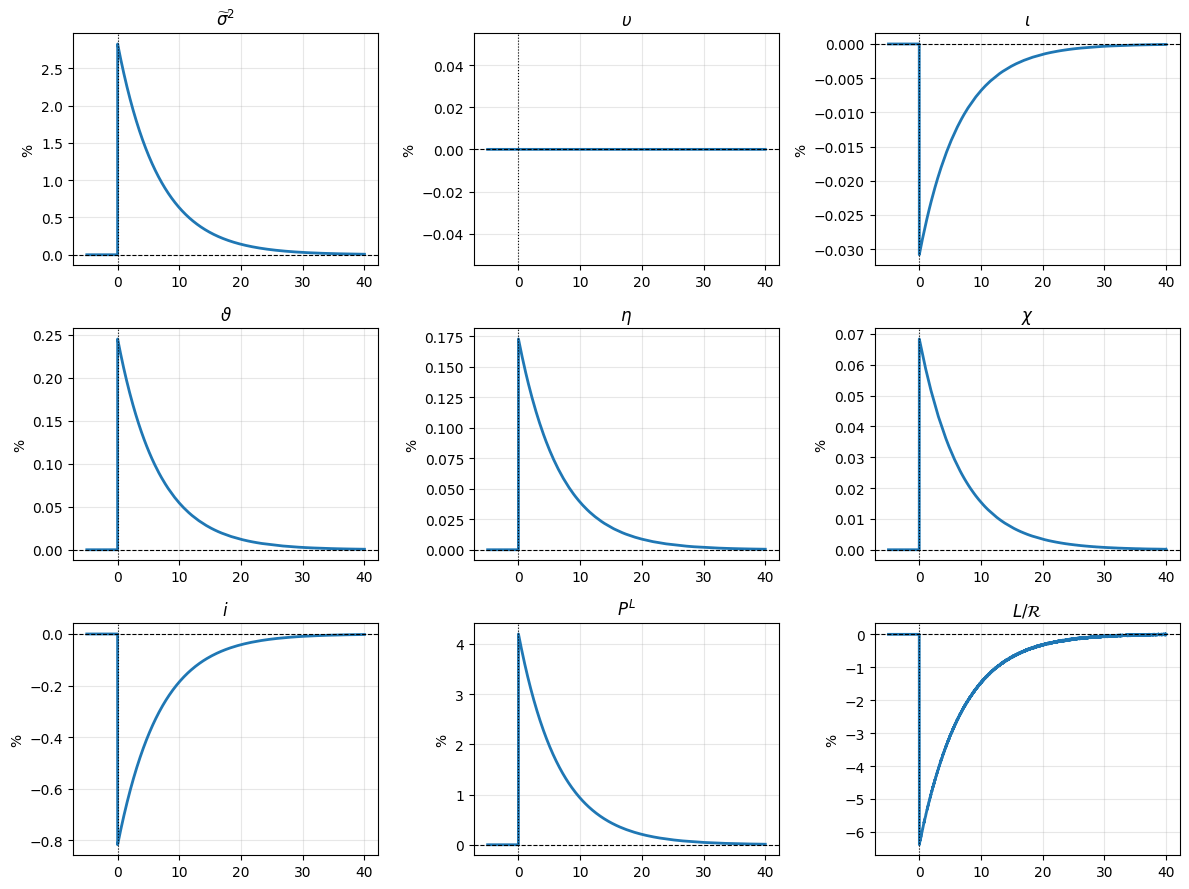

In [9]:
irf = simulate_irf(model, shock=dZ, horizon=T_irf, dt=dt_irf, pre_shock=ap)
plot_irf(irf, MODEL_PATH)